# AI-Assisted Linear Regression in Python

This notebook uses Python to examine the relationship between years of experience and salary. It loads the dataset, visualizes the variables, fits a linear regression model, and evaluates the model.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

In [4]:
data = pd.read_csv("regression_data-1.csv")

print("First five rows:")
display(data.head())

print("\nDataset information:")
data.info()

First five rows:


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  10 non-null     float64
 1   Salary           10 non-null     float64
dtypes: float64(2)
memory usage: 288.0 bytes


In [5]:
required_columns = ["YearsExperience", "Salary"]

missing_columns = [
    column for column in required_columns
    if column not in data.columns
]

if missing_columns:
    raise ValueError(
        "Missing required column(s): "
        + ", ".join(missing_columns)
    )

data["YearsExperience"] = pd.to_numeric(
    data["YearsExperience"],
    errors="coerce"
)

data["Salary"] = pd.to_numeric(
    data["Salary"],
    errors="coerce"
)

data = data.dropna(
    subset=["YearsExperience", "Salary"]
).copy()

print("Number of usable observations:", len(data))

Number of usable observations: 10


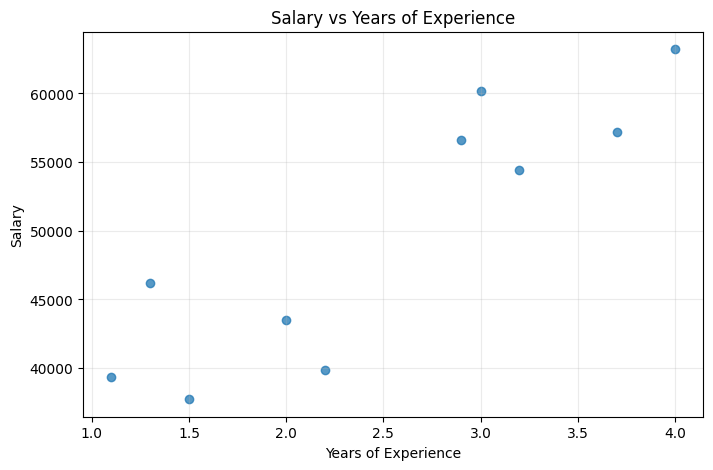

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["YearsExperience"],
    data["Salary"],
    alpha=0.75
)

plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.grid(alpha=0.25)
plt.show()

In [9]:
X = data[["YearsExperience"]]
y = data["Salary"]

model = LinearRegression()
model.fit(X, y)

predicted_salary = model.predict(X)

In [10]:
r_squared = model.score(X, y)

rmse = np.sqrt(
    mean_squared_error(y, predicted_salary)
)

print(f"Intercept: {model.intercept_:.2f}")
print(f"Slope: {model.coef_[0]:.2f}")
print(f"R-squared: {r_squared:.4f}")
print(f"RMSE: {rmse:.2f}")

Intercept: 29203.52
Slope: 8285.29
R-squared: 0.7852
RMSE: 4186.15


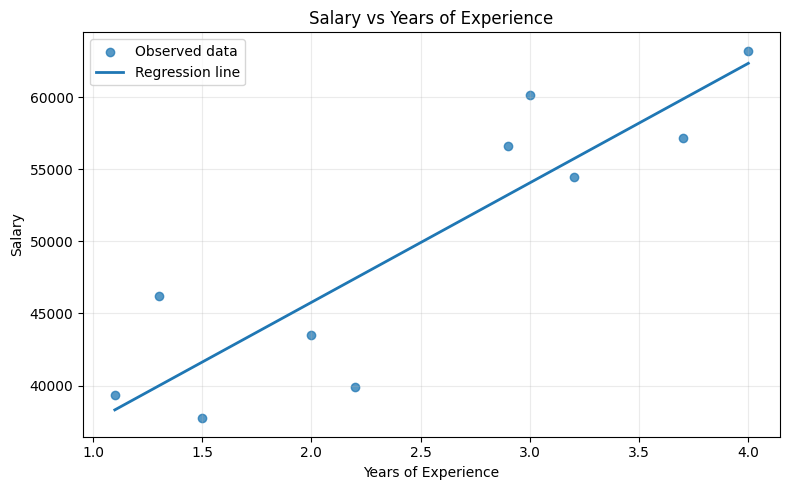

In [11]:
plot_data = data.copy()
plot_data["PredictedSalary"] = predicted_salary
plot_data = plot_data.sort_values("YearsExperience")

plt.figure(figsize=(8, 5))

plt.scatter(
    data["YearsExperience"],
    data["Salary"],
    alpha=0.75,
    label="Observed data"
)

plt.plot(
    plot_data["YearsExperience"],
    plot_data["PredictedSalary"],
    linewidth=2,
    label="Regression line"
)

plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()